In [57]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from pennylane import qchem
import pprint
import scipy

In [58]:
part = qml.data.load(
    "qchem",
    molname="LiH",
    basis="STO-3G",
    bondlength=1.57,
    attributes=["hamiltonian", "hf_state", "fci_energy"])[0]

H = part.hamiltonian
hf = part.hf_state
print(part.hamiltonian)
print(part.hf_state)

-4.126288480473631 * I([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]) + 1.0077255780681387 * Z(0) + 0.014553995928425625 * (Y(0) @ Z(1) @ Y(2)) + 0.014553995928425625 * (X(0) @ Z(1) @ X(2)) + 0.02546468672959524 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Y(4)) + 0.02546468672959524 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ X(4)) + -0.0012383446511483713 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + -0.0012383446511483713 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ X(10)) + -0.1174738707224526 * Z(2) + 0.08917616185531785 * (Z(0) @ Z(2)) + -0.007569062960309601 * (Y(2) @ Z(3) @ Y(4)) + -0.007569062960309601 * (X(2) @ Z(3) @ X(4)) + -0.0003796394606089663 * (Z(0) @ Y(2) @ Z(3) @ Y(4)) + -0.0003796394606089663 * (Z(0) @ X(2) @ Z(3) @ X(4)) + 0.005686406710228088 * (Y(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + 0.005686406710228088 * (X(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ X(10)) + 0.007293733203099428 * (Z(0) @ Y(2) @ 

In [59]:
elements  = ['Li', 'H']
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.548]])

H, n_qubits = qchem.molecular_hamiltonian(elements, geometry, basis='STO-3G')

generators = qml.qchem.symmetry_generators(H)
pprint.pprint(f'Generators: {generators}')

('Generators: [Z(6) @ Z(7), Z(8) @ Z(9), Z(0) @ Z(2) @ Z(4) @ Z(6) @ Z(8) @ '
 'Z(10), Z(1) @ Z(3) @ Z(5) @ Z(6) @ Z(8) @ Z(11)]')


In [60]:
paulix = qml.qchem.paulix_ops(generators, n_qubits)
print(f'Paulix operators: {paulix}')
n_electrons = 4
eigenvalues_x = qml.qchem.optimal_sector(H, generators, n_electrons)

H_taper = qml.qchem.taper(H, generators, paulix, paulix_sector=eigenvalues_x)
qubits_taper = n_qubits - len(generators)
print(f'Tapered Hamiltonian: {H_taper}')
print(f'Qubits tapered: {qubits_taper}')

hf_taper = qml.qchem.taper_hf(generators, paulix, eigenvalues_x, num_electrons=n_electrons, num_wires=n_qubits)

Paulix operators: [X(7), X(9), X(10), X(11)]
Tapered Hamiltonian: -3.6540007226060314 * I([0, 1, 2, 3, 4, 5, 6, 7]) + -0.3843806537985153 * (Z(1) @ Z(3) @ Z(5) @ Z(6) @ Z(7)) + -0.3843806537985153 * (Z(0) @ Z(2) @ Z(4) @ Z(6) @ Z(7)) + 0.10947208442930706 * (Z(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5)) + -0.4252911379405724 * Z(7) + 0.13544881186766763 * (Z(1) @ Z(3) @ Z(5) @ Z(6)) + 0.13544881186766763 * (Z(0) @ Z(2) @ Z(4) @ Z(6)) + -0.42529113794042855 * Z(6) + 0.13544881186760482 * (Z(1) @ Z(3) @ Z(5) @ Z(7)) + 0.13544881186760482 * (Z(0) @ Z(2) @ Z(4) @ Z(7)) + 0.2707726146524773 * (Z(6) @ Z(7)) + 1.0705469426986656 * Z(0) + 0.10992676391338095 * (Z(0) @ Z(1) @ Z(3) @ Z(5) @ Z(6) @ Z(7)) + 0.1035849327793079 * (Z(2) @ Z(4) @ Z(6) @ Z(7)) + 0.19544588650724906 * (Z(0) @ Z(7)) + 0.19544588650715858 * (Z(0) @ Z(6)) + 0.06136869549706245 * (Z(2) @ Z(4)) + -0.02794501056263994 * (Y(0) @ Z(1) @ Y(2)) + 0.004107052689959366 * (Y(0) @ Y(2) @ Z(3) @ Z(5) @ Z(6) @ Z(7)) + -0.00145892492176487 *

Step 0, Energy: -7.635694
Step 10, Energy: -7.628142
Step 20, Energy: -7.633720
Step 30, Energy: -7.635415
Step 40, Energy: -7.635691
Step 50, Energy: -7.635797
Step 60, Energy: -7.635870
Step 70, Energy: -7.635883
Step 80, Energy: -7.635881
Step 90, Energy: -7.635887
Exact energy: -7.653948
Final VQE energy: -7.635887
Energy difference: 0.018061


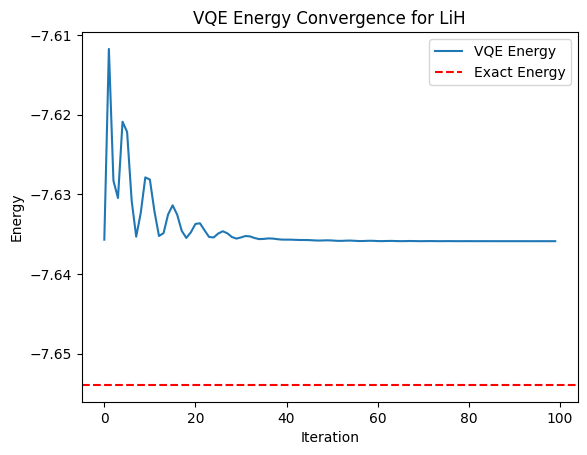

In [61]:
dev = qml.device('default.qubit', wires=qubits_taper)

singles, doubles = qml.qchem.excitations(n_electrons, qubits_taper)

@qml.qnode(dev)
def circuit(params):
    # AllSinglesDoubles internally applies BasisState(hf_taper) first,
    # then the parameterized excitation gates
    qml.AllSinglesDoubles(params, wires=range(qubits_taper), hf_state=hf_taper, singles=singles, doubles=doubles)
    return qml.expval(H_taper)

n_params = len(singles) + len(doubles)
# Initialize near zero — large random init (std=pi) prevents convergence
params = np.zeros(n_params, requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

energies = []
for step in range(100):
    params, energy = opt.step_and_cost(circuit, params)
    energies.append(energy)
    if step % 10 == 0:
        print(f'Step {step}, Energy: {energy:.6f}')

# wire_order required so the matrix is built on the correct qubit ordering
H_matrix = qml.matrix(H_taper, wire_order=range(qubits_taper))
exact_energy = np.linalg.eigvalsh(H_matrix)[0]
print(f'Exact energy: {exact_energy:.6f}')
print(f'Final VQE energy: {energies[-1]:.6f}')
print(f'Energy difference: {energies[-1] - exact_energy:.6f}')
plt.plot(energies, label='VQE Energy')
plt.axhline(exact_energy, color='red', linestyle='--', label='Exact Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('VQE Energy Convergence for LiH')
plt.legend()
plt.show()


Step 0, Energy: -7.635694
Step 10, Energy: -7.635813
Step 20, Energy: -7.635847
Step 30, Energy: -7.635865
Step 40, Energy: -7.635875
Step 50, Energy: -7.635880
Step 60, Energy: -7.635883
Step 70, Energy: -7.635885
Step 80, Energy: -7.635886
Step 90, Energy: -7.635886
Exact energy: -7.653948
Final VQE energy: -7.635887
Energy difference: 0.018061


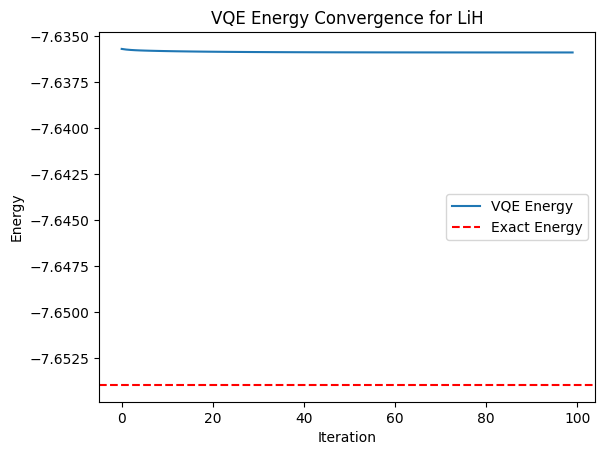

In [62]:
dev = qml.device('default.qubit', wires=qubits_taper)

singles, doubles = qml.qchem.excitations(n_electrons, qubits_taper)

@qml.qnode(dev)
def circuit(params):
    # AllSinglesDoubles internally applies BasisState(hf_taper) first,
    # then the parameterized excitation gates
    qml.AllSinglesDoubles(params, wires=range(qubits_taper), hf_state=hf_taper, singles=singles, doubles=doubles)
    return qml.expval(H_taper)

n_params = len(singles) + len(doubles)
# Initialize near zero — large random init (std=pi) prevents convergence
params = np.zeros(n_params, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.1)

energies = []
for step in range(100):
    params, energy = opt.step_and_cost(circuit, params)
    energies.append(energy)
    if step % 10 == 0:
        print(f'Step {step}, Energy: {energy:.6f}')

# wire_order required so the matrix is built on the correct qubit ordering
H_matrix = qml.matrix(H_taper, wire_order=range(qubits_taper))
exact_energy = np.linalg.eigvalsh(H_matrix)[0]
print(f'Exact energy: {exact_energy:.6f}')
print(f'Final VQE energy: {energies[-1]:.6f}')
print(f'Energy difference: {energies[-1] - exact_energy:.6f}')
plt.plot(energies, label='VQE Energy')
plt.axhline(exact_energy, color='red', linestyle='--', label='Exact Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('VQE Energy Convergence for LiH')
plt.legend()
plt.show()
